In [1]:
import sys
!{sys.executable} -m pip install -q 'scanpy[leiden]'


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: /n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/bin/python -m pip install --upgrade pip


In [2]:
import scanpy as sc
import scipy as sp
import numpy as np
import matplotlib.pylab as pl
import ot

In [42]:
n_samples = 500

In [43]:
pig_adata = sc.read_10x_mtx('../data/pig/')

In [44]:
# preprocessing pig
pig_adata.var_names_make_unique()
sc.pp.filter_cells(pig_adata, min_genes=100)
sc.pp.filter_genes(pig_adata, min_cells=3)
pig_adata.layers["counts"] = pig_adata.X.copy()
sc.pp.normalize_total(pig_adata)
sc.pp.log1p(pig_adata)
sc.pp.highly_variable_genes(pig_adata, n_top_genes=2000)
sc.tl.pca(pig_adata)

In [45]:
# labeling cell types on pig
sc.pp.neighbors(pig_adata)
sc.tl.umap(pig_adata)

In [46]:
pig_adata.obs['leiden']=None

In [47]:
sc.tl.leiden(pig_adata, flavor="igraph", n_iterations=2, resolution=0.1)

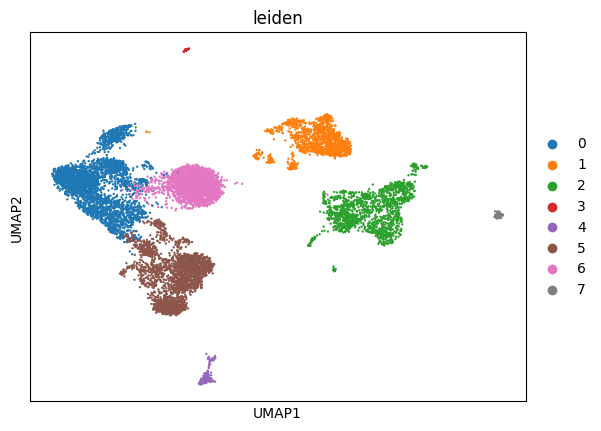

In [48]:
sc.pl.umap(pig_adata, color=["leiden"])

In [49]:
# based on Figure 4C in this paper: https://www.frontiersin.org/journals/genetics/articles/10.3389/fgene.2021.689406/full
pig_marker_genes = {
    "Mono": ["FCN1", "CD14"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "FCER1A"],
    "Erythroblast": ["HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP"],
    "ILC": ["ID2", "PLCG2", "GNLY"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "FCRL1"],
    # Note IGHD and IGHM are negative markers
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK"
    ],
    "Plasma cells": ["MZB1", "FNDC3B", "PRDM1", "JCHAIN"],
    # Note PAX5 is a negative marker
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "COBLL1", "TCF4"],
}

In [50]:
sc.tl.rank_genes_groups(pig_adata, groupby="leiden", method="wilcoxon")
sc.get.rank_genes_groups_df(pig_adata, group="7").head(10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,CST3,13.813948,8.788404,2.099997e-43,5.882923e-40
1,CTSS,13.812932,6.171508,2.129841e-43,5.882923e-40
2,ENSSSCG00000028944,13.808948,10.730721,2.250957e-43,5.882923e-40
3,SMIM5,13.807972,10.940986,2.281648e-43,5.882923e-40
4,PLA2G7,13.806183,10.188181,2.339000e-43,5.882923e-40
5,ENSSSCG00000010077,13.801915,9.487645,2.481723e-43,5.882923e-40
6,ATP13A2,13.786833,6.413950,3.058991e-43,6.215433e-40
7,IRF8,13.777076,5.849184,3.501713e-43,6.225608e-40
8,CCDC50,13.739248,5.313964,5.908612e-43,8.782460e-40
9,PLAC8,13.736057,3.279623,6.174829e-43,8.782460e-40


In [51]:
pig_leiden_cell_types = {"0":"T/NK",
                           "1":"B",
                           "2":"Monocyte/DC",
                           "3":"Megakaryocyte",
                           "4":"Erythrocyte",
                           "5":"T/NK",
                           "6":"T/NK",
                           "7":"Monocyte/DC"
                          }

In [52]:
pig_cell_type_labels = [pig_leiden_cell_types[cluster] for cluster in pig_adata.obs['leiden']]
pig_adata.obs['cell_types'] = pig_cell_type_labels

In [53]:
pig_small = sc.pp.subsample(pig_adata, n_obs=n_samples, copy=True)

In [54]:
human_adata = sc.read_10x_h5('../data/human/pbmc_10k_v3_raw_feature_bc_matrix.h5')

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [55]:
# preprocessing pig
human_adata.var_names_make_unique()
sc.pp.filter_cells(human_adata, min_genes=100)
sc.pp.filter_genes(human_adata, min_cells=3)
human_adata.layers["counts"] = human_adata.X.copy()
sc.pp.normalize_total(human_adata)
sc.pp.log1p(human_adata)
sc.pp.highly_variable_genes(human_adata, n_top_genes=2000)
sc.tl.pca(human_adata)

In [56]:
# labeling cell types on pig
sc.pp.neighbors(human_adata)
sc.tl.umap(human_adata)

In [57]:
sc.tl.leiden(human_adata, flavor="igraph", n_iterations=2, resolution=0.2)

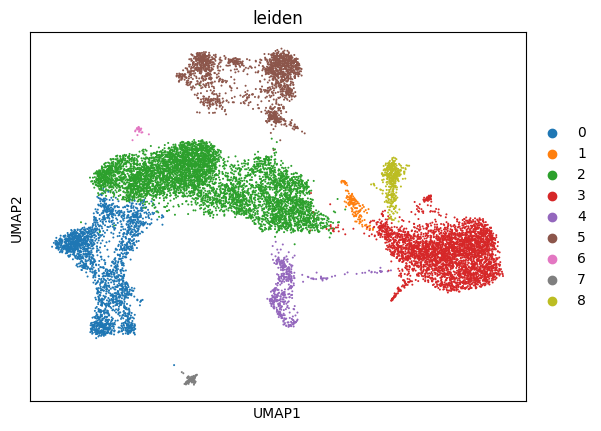

In [58]:
sc.pl.umap(human_adata, color=["leiden"])

In [59]:
human_leiden_cell_types = {"0":"T/NK",
                           "1":"Monocyte/DC",
                           "2":"T/NK",
                           "3":"Monocyte/DC",
                           "4":"Megakaryocyte",
                           "5":"B",
                           "6":"Multipotent Progenitor",
                           "7":"pDC",
                           "8":"Macrophage"
                          }

In [60]:
human_cell_type_labels = [human_leiden_cell_types[cluster] for cluster in human_adata.obs['leiden']]
human_adata.obs['cell_types'] = human_cell_type_labels

In [61]:
human_small = sc.pp.subsample(human_adata, n_obs=n_samples, copy=True)

# Now run OT with 50 dims

In [135]:
xs = pig_small.obsm['X_pca']
xt = human_small.obsm['X_pca']

In [136]:
xs.std()

np.float32(1.1882412)

In [137]:
xt.std()

np.float32(1.0675997)

In [138]:
pig_small.obsm['X_pca'].shape

(500, 50)

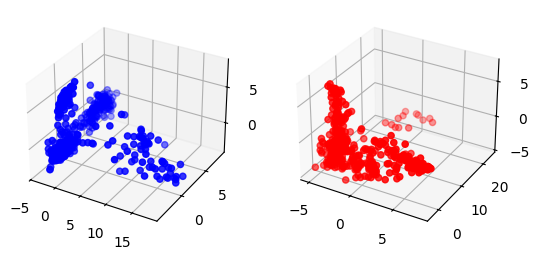

In [139]:
fig = pl.figure(1)
ax2 = fig.add_subplot(121, projection="3d")
ax2.scatter(xs[:, 0], xs[:, 1], xs[:, 2], color="b")
ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(xt[:, 0], xt[:, 1], xt[:, 2], color="r")
pl.show()

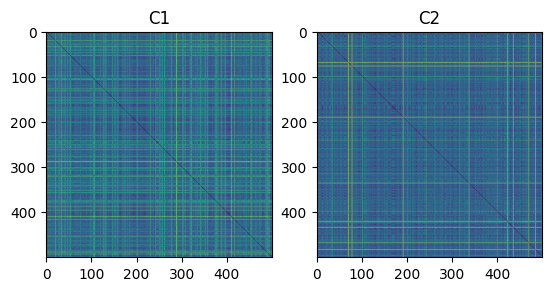

In [140]:
C1 = sp.spatial.distance.cdist(xs, xs)
C2 = sp.spatial.distance.cdist(xt, xt)

C1 /= C1.max()
C2 /= C2.max()

pl.figure(2)
pl.subplot(121)
pl.imshow(C1)
pl.title("C1")

pl.subplot(122)
pl.imshow(C2)
pl.title("C2")

pl.show()

In [131]:
p = ot.unif(n_samples)
q = ot.unif(n_samples)

# Conditional Gradient algorithm
gw0, log0 = ot.gromov.gromov_wasserstein(
    C1, C2, p, q, "square_loss", verbose=True, log=True
)

# Proximal Point algorithm with Kullback-Leibler as proximal operator
gw, log = ot.gromov.entropic_gromov_wasserstein(
    C1, C2, p, q, "square_loss", epsilon=5e-4, solver="PPA", log=True, verbose=True
)

# Projected Gradient algorithm with entropic regularization
gwe, loge = ot.gromov.entropic_gromov_wasserstein(
    C1, C2, p, q, "square_loss", epsilon=5e-4, solver="PGD", log=True, verbose=True
)

print(
    "Gromov-Wasserstein distance estimated with Conditional Gradient solver: "
    + str(log0["gw_dist"])
)
print(
    "Gromov-Wasserstein distance estimated with Proximal Point solver: "
    + str(log["gw_dist"])
)
print(
    "Entropic Gromov-Wasserstein distance estimated with Projected Gradient solver: "
    + str(loge["gw_dist"])
)

# compute OT sparsity level
gw0_sparsity = 100 * (gw0 == 0.0).astype(np.float64).sum() / (n_samples**2)
gw_sparsity = 100 * (gw == 0.0).astype(np.float64).sum() / (n_samples**2)
gwe_sparsity = 100 * (gwe == 0.0).astype(np.float64).sum() / (n_samples**2)

# Methods using Sinkhorn projections tend to produce feasibility errors on the
# marginal constraints

err0 = np.linalg.norm(gw0.sum(1) - p) + np.linalg.norm(gw0.sum(0) - q)
err = np.linalg.norm(gw.sum(1) - p) + np.linalg.norm(gw.sum(0) - q)
erre = np.linalg.norm(gwe.sum(1) - p) + np.linalg.norm(gwe.sum(0) - q)

pl.figure(3, (10, 6))
cmap = "Blues"
fontsize = 12
pl.subplot(131)
pl.imshow(gw0, cmap=cmap)
pl.title(
    "(CG algo) GW=%s \n  \n OT sparsity=%s \n feasibility error=%s"
    % (
        np.round(log0["gw_dist"], 4),
        str(np.round(gw0_sparsity, 2)) + " %",
        np.round(np.round(err0, 4)),
    ),
    fontsize=fontsize,
)

pl.subplot(132)
pl.imshow(gw, cmap=cmap)
pl.title(
    "(PP algo) GW=%s \n  \n OT sparsity=%s \nfeasibility error=%s"
    % (
        np.round(log["gw_dist"], 4),
        str(np.round(gw_sparsity, 2)) + " %",
        np.round(err, 4),
    ),
    fontsize=fontsize,
)

pl.subplot(133)
pl.imshow(gwe, cmap=cmap)
pl.title(
    "Entropic GW=%s \n  \n OT sparsity=%s \nfeasibility error=%s"
    % (
        np.round(loge["gw_dist"], 4),
        str(np.round(gwe_sparsity, 2)) + " %",
        np.round(erre, 4),
    ),
    fontsize=fontsize,
)

pl.tight_layout()
pl.show()

ValueError: shapes (10,10) and (500,1) not aligned: 10 (dim 1) != 500 (dim 0)

In [ ]:
np.sum(gw)

### Next steps
1. Identify predicted human cell for each pig cell
2. Label cell types
3. Visualize / quantify whether cell types were correctly paired
4. Repeat with two mice and two humans

In [132]:
# identify predicted human cell for each pig cell
argmax_arr = np.argmax(gw0, axis=1) # row sum

In [133]:
np.argmax([[0,1],[2,3]], axis=1)

array([1, 1])

In [111]:
cell_pairs = []
cell_type_pairs = []
for pig_cell_num in range(len(argmax_arr)):
    human_cell_num = int(argmax_arr[pig_cell_num])
    cell_pairs.append((pig_cell_num, human_cell_num))
    cell_type_pairs.append((pig_small.obs['cell_types'][pig_cell_num], 
                            human_small.obs['cell_types'][human_cell_num]))

/tmp/ipykernel_1250478/247454343.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cell_type_pairs.append((pig_small.obs['cell_types'][pig_cell_num],
/tmp/ipykernel_1250478/247454343.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  human_small.obs['cell_types'][human_cell_num]))


In [112]:
cell_type_pairs

[('T/NK', 'T/NK'),
 ('T/NK', 'T/NK'),
 ('B', 'T/NK'),
 ('B', 'B'),
 ('T/NK', 'T/NK'),
 ('T/NK', 'T/NK'),
 ('T/NK', 'T/NK'),
 ('B', 'B'),
 ('T/NK', 'Monocyte/DC'),
 ('Monocyte/DC', 'T/NK'),
 ('B', 'B'),
 ('T/NK', 'T/NK'),
 ('T/NK', 'T/NK'),
 ('T/NK', 'T/NK'),
 ('T/NK', 'Macrophage'),
 ('Monocyte/DC', 'T/NK'),
 ('T/NK', 'Monocyte/DC'),
 ('T/NK', 'Monocyte/DC'),
 ('T/NK', 'T/NK'),
 ('B', 'T/NK'),
 ('T/NK', 'T/NK'),
 ('Monocyte/DC', 'Megakaryocyte'),
 ('B', 'T/NK'),
 ('T/NK', 'T/NK'),
 ('T/NK', 'Monocyte/DC'),
 ('T/NK', 'Monocyte/DC'),
 ('T/NK', 'T/NK'),
 ('Monocyte/DC', 'T/NK'),
 ('B', 'B'),
 ('Monocyte/DC', 'T/NK'),
 ('B', 'T/NK'),
 ('T/NK', 'B'),
 ('T/NK', 'T/NK'),
 ('Monocyte/DC', 'Megakaryocyte'),
 ('T/NK', 'B'),
 ('T/NK', 'T/NK'),
 ('T/NK', 'T/NK'),
 ('T/NK', 'T/NK'),
 ('T/NK', 'Monocyte/DC'),
 ('B', 'T/NK'),
 ('T/NK', 'T/NK'),
 ('Erythrocyte', 'T/NK'),
 ('B', 'B'),
 ('Monocyte/DC', 'T/NK'),
 ('T/NK', 'Monocyte/DC'),
 ('T/NK', 'T/NK'),
 ('T/NK', 'T/NK'),
 ('Monocyte/DC', 'T/NK'),
 ('

In [113]:
np.mean([1 if cell_type_pairs[i][0] == cell_type_pairs[i][1] else 0 for i in range(len(cell_type_pairs))])

np.float64(0.432)

In [114]:
pig_labels_random = pig_small.obs['cell_types'].sample(frac=1)
human_labels_random = human_small.obs['cell_types'].sample(frac=1)

In [115]:
cell_pairs_random = []
cell_type_pairs_random = []
for col in range(len(argmax_arr)):
    pig_cell_num = col
    human_cell_num = int(argmax_arr[col])
    cell_pairs_random.append((pig_cell_num, human_cell_num))
    cell_type_pairs_random.append((pig_labels_random[pig_cell_num], 
                            human_labels_random[human_cell_num]))

/tmp/ipykernel_1250478/3978987.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cell_type_pairs_random.append((pig_labels_random[pig_cell_num],
/tmp/ipykernel_1250478/3978987.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  human_labels_random[human_cell_num]))


In [116]:
np.mean([1 if cell_type_pairs_random[i][0] == cell_type_pairs_random[i][1] else 0 for i in range(len(cell_type_pairs_random))])

np.float64(0.456)

### Cell type abundances

In [91]:
pig_small.obs['cell_types'].value_counts()

cell_types
T/NK             363
Monocyte/DC       75
B                 56
Erythrocyte        3
Megakaryocyte      3
Name: count, dtype: int64

In [92]:
human_small.obs['cell_types'].value_counts()

cell_types
T/NK             275
Monocyte/DC      123
B                 59
Megakaryocyte     20
Macrophage        20
pDC                3
Name: count, dtype: int64